# 10 — Analyse de First Copilot, dédupliqué

**Objectif** — hiérarchiser les problèmes visibles dans First Copilot
(catégorie, sous-motif, agence, canal, montant, résolution), sur le
périmètre dédupliqué du notebook 09 : sans cette étape, un sous-motif
sur-représenté dans les tickets `INTERCOM` ressaisis compterait deux fois
(une fois côté A, une fois ici).

| | |
|---|---|
| **Entrée** | First Copilot (notebook 08) + table de correspondance (notebook 09) |
| **Sorties** | `resultats/tables/10_*.csv` + figures |
| **Suite** | notebook 11 — validation croisée ; notebook 12 — synthèse consolidée |

Ce notebook recharge et redéduplique sa source plutôt que de dépendre d'un
état écrit par le notebook 09 — même convention que le reste de `niv/` :
chaque notebook est autonome.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from reclamations import chargement, config, consolidation, systeme_b, viz

viz.appliquer_charte()
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 100)

# Système A -- necessaire uniquement pour redupliquer B (notebook 09)
tickets_a = chargement.perimetre_operationnel(chargement.typer(chargement.charger_brut()))

# First Copilot
tickets = systeme_b.charger_tickets()
categories = systeme_b.charger_categories()
groups = systeme_b.charger_groups()
champs, valeurs = systeme_b.charger_champs_personnalises()
conversations = systeme_b.charger_conversations()

# Dedoublonnage (notebook 09)
cles_a = consolidation.cles_a(tickets_a)
cles_b = consolidation.cles_b(tickets, champs, valeurs)
paires = consolidation.apparier(cles_a, cles_b)
base = consolidation.tickets_b_non_apparies(tickets, paires)

print(f"First Copilot avant dédoublonnage : {len(tickets):,}")
print(f"First Copilot après dédoublonnage : {len(base):,}  ({len(base) / len(tickets) * 100:.1f} %)")

/home/gauss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


First Copilot avant dédoublonnage : 8,005
First Copilot après dédoublonnage : 6,828  (85.3 %)


## 1. Volumes par catégorie et canal, périmètre dédupliqué

  -> resultats/tables/10_categories_dedupliquees.csv


  -> resultats/figures/10_categories_dedupliquees.png


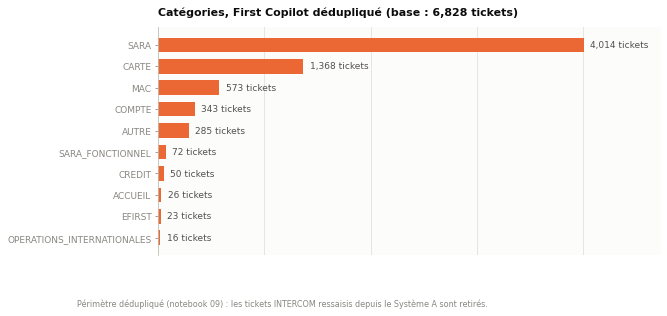

,effectif,pct
name,,
SARA,4014,58.8
CARTE,1368,20.0
MAC,573,8.4
COMPTE,343,5.0
AUTRE,285,4.2
SARA_FONCTIONNEL,72,1.1
CREDIT,50,0.7
ACCUEIL,26,0.4
EFIRST,23,0.3


In [2]:
cat = base["category_id"].value_counts().rename("effectif").to_frame()
cat = cat.join(categories.set_index("id")["name"]).set_index("name")
cat["pct"] = (cat["effectif"] / len(base) * 100).round(1)
chargement.sauver_table(cat[["effectif", "pct"]], "10_categories_dedupliquees")

fig, ax = plt.subplots(figsize=(9, 4.2))
viz.barres_horizontales(
    cat["effectif"].sort_values(ascending=False).head(10),
    f"Catégories, First Copilot dédupliqué (base : {len(base):,} tickets)",
    unite=" tickets",
    couleur=viz.SERIES[1],
    ax=ax,
    format_valeur="{:,.0f}",
)
viz.annoter_source(fig, "Périmètre dédupliqué (notebook 09) : les tickets INTERCOM ressaisis depuis le Système A sont retirés.")
viz.sauver(fig, "10_categories_dedupliquees")
plt.show()

cat[["effectif", "pct"]].sort_values("effectif", ascending=False)

## 2. Sous-motifs — la taxonomie annotée à la main, sur la base dédupliquée

In [3]:
sm = systeme_b.sous_motifs(champs, valeurs)
sm_base = sm.loc[sm.index.isin(base["id"])]
print(f"Tickets qualifiés (base dédupliquée) : {len(sm_base):,} / {len(base):,} ({len(sm_base) / len(base) * 100:.1f} %)")

resume_sm = sm_base.groupby(["domaine", "sous_motif"]).size().rename("effectif").reset_index()
resume_sm["pct_domaine"] = resume_sm.groupby("domaine")["effectif"].transform(lambda s: (s / s.sum() * 100).round(1))
resume_sm = resume_sm.sort_values(["domaine", "effectif"], ascending=[True, False])
chargement.sauver_table(resume_sm, "10_sous_motifs_deduplique", index=False)
resume_sm

Tickets qualifiés (base dédupliquée) : 5,457 / 6,828 (79.9 %)
  -> resultats/tables/10_sous_motifs_deduplique.csv


,domaine,sous_motif,effectif,pct_domaine
4,Sous domaine Monetique,Opérations GAB AFB,695,54.1
3,Sous domaine Monetique,Opérations GAB,288,22.4
0,Sous domaine Monetique,Autre,91,7.1
8,Sous domaine Monetique,Versement GAB,74,5.8
7,Sous domaine Monetique,Paiement En Ligne,71,5.5
5,Sous domaine Monetique,Opérations GAB Confrère,41,3.2
6,Sous domaine Monetique,Opérations TPE,22,1.7
1,Sous domaine Monetique,Carte Blanche,2,0.2
2,Sous domaine Monetique,Carte Volée,1,0.1
11,Sous domaine Operations bancaire,Problème Cash Deposit,129,33.7


  -> resultats/figures/10_sous_motifs_sara.png


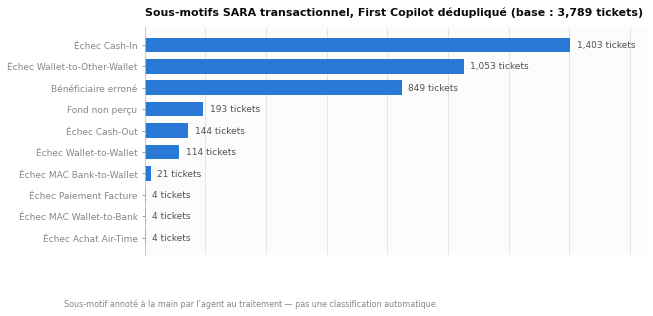

In [4]:
sara = resume_sm[resume_sm["domaine"] == "Sous domaine Sara transactionnel"].set_index("sous_motif")["effectif"]

fig, ax = plt.subplots(figsize=(9, 4.2))
viz.barres_horizontales(
    sara,
    f"Sous-motifs SARA transactionnel, First Copilot dédupliqué (base : {int(sara.sum()):,} tickets)",
    unite=" tickets",
    ax=ax,
    format_valeur="{:,.0f}",
)
viz.annoter_source(fig, "Sous-motif annoté à la main par l'agent au traitement — pas une classification automatique.")
viz.sauver(fig, "10_sous_motifs_sara")
plt.show()

## 3. Agences — une dimension géographique absente du Système A

`source_group_id` mélange agences physiques (`FIRST_BANK_*`) et services
internes (notebook 08, § 2). Seules les agences sont retenues ici.

In [5]:
noms_groupes = base["source_group_id"].map(groups.set_index("id")["group_name"])
est_agence = noms_groupes.str.startswith("FIRST_BANK_", na=False)
agences = noms_groupes[est_agence].value_counts().rename("effectif").to_frame()
agences["pct_du_perimetre_agence"] = (agences["effectif"] / est_agence.sum() * 100).round(1)
chargement.sauver_table(agences.head(20), "10_agences_dedupliquees")

print(f"Tickets rattachés à une agence : {est_agence.sum():,} / {len(base):,} ({est_agence.mean() * 100:.1f} %)")
agences.head(15)

  -> resultats/tables/10_agences_dedupliquees.csv
Tickets rattachés à une agence : 2,807 / 6,828 (41.1 %)


,effectif,pct_du_perimetre_agence
source_group_id,,
FIRST_BANK_HIPPODROME,255,9.1
FIRST_BANK_NGAOUNDERE,254,9.0
FIRST_BANK_MESSAMENDONGO,107,3.8
FIRST_BANK_KRIBI,101,3.6
FIRST_BANK_FENETRE_ISLAMIQUE_YAOUNDE,100,3.6
FIRST_BANK_DSCHANG,92,3.3
FIRST_BANK_MAROUA,85,3.0
FIRST_BANK_BONAMOUSSADI,80,2.9
FIRST_BANK_NDOKOTTI,77,2.7


## 4. Exposition financière par sous-motif

Même réserve que partout ailleurs dans ce projet : ordre de grandeur, jamais
un chiffre officiel (`config.MONTANT_PLAFOND_PLAUSIBLE_B`, notebook 08 § 6).

In [6]:
montants = systeme_b.montants_plausibles(champs, valeurs)
montants_base = montants.loc[montants.index.isin(base["id"])]

sm_montant = sm_base.join(montants_base.rename("montant"), how="inner")
expo = sm_montant.groupby("sous_motif")["montant"].agg(tickets="count", mediane="median").sort_values("tickets", ascending=False)
chargement.sauver_table(expo.round(0), "10_exposition_par_sous_motif")
expo.round(0).head(15)

  -> resultats/tables/10_exposition_par_sous_motif.csv


,tickets,mediane
sous_motif,,
Échec Cash-In,1384,60000.0
Échec Wallet-to-Other-Wallet,1034,49000.0
Bénéficiaire erroné,839,48000.0
Opérations GAB AFB,677,150000.0
Opérations GAB,281,150000.0
Fond non perçu,192,50000.0
Autre,164,150000.0
Échec Cash-Out,142,57500.0
Problème Cash Deposit,128,370000.0


## 5. Résolution — ce que le Système A ne permet pas de mesurer

`created_at → resolved_on` uniquement (`systeme_b.delai_resolution`) —
jamais `closed_on`, artefact de clôture automatique (notebook 08 § 4).

In [7]:
statut = base["status"].value_counts().rename("effectif").to_frame()
statut["pct"] = (statut["effectif"] / len(base) * 100).round(1)
chargement.sauver_table(statut, "10_statuts_deduplique")

delai = systeme_b.delai_resolution(base) / 24  # heures -> jours
print(f"Taux 'résolu' (RESOLU + FERME) : {base['status'].isin(['RESOLU', 'FERME']).mean() * 100:.1f} %")
print(f"Délai créé -> résolu, médiane  : {delai.median():.1f} jours  (n={delai.notna().sum():,})")
print()
print(statut)

  -> resultats/tables/10_statuts_deduplique.csv
Taux 'résolu' (RESOLU + FERME) : 85.3 %
Délai créé -> résolu, médiane  : 9.6 jours  (n=5,036)

                           effectif   pct
status                                   
FERME                          5073  74.3
RESOLU                          750  11.0
TRANSFERE_POUR_TRAITEMENT       604   8.8
OUVERT                          218   3.2
EN_COURS                        183   2.7


In [8]:
# solution = colonne sensible (config.FRAGMENTS_COLONNES_SENSIBLES) : la table de
# resultats/ ne recoit que des agregats, jamais le texte lui-meme.
solution_remplie = base["solution"].notna()
print(f"Champ 'solution' rempli : {solution_remplie.sum():,} / {len(base):,} ({solution_remplie.mean() * 100:.1f} %)")
print(f"Longueur médiane (rempli) : {base.loc[solution_remplie, 'solution'].str.len().median():.0f} caractères")

Champ 'solution' rempli : 4,163 / 6,828 (61.0 %)
Longueur médiane (rempli) : 49 caractères


## Ce que ce notebook établit

1. Le périmètre B dédupliqué (notebook 09) est analysé sans double-compte
   avec le Système A.
2. Deux dimensions inédites, absentes de A : le sous-motif annoté à la main
   (§ 2) et l'agence d'origine (§ 3).
3. Un taux de résolution et un délai de traitement réels sont mesurables
   (§ 5) — bloqués côté A (protocole § 5.3, statut `submitted` ambigu).
4. **Réserve à ne pas oublier** : dédupliqué ne veut pas dire « canaux
   physiques uniquement ». `INTERCOM` reste le premier canal du périmètre B
   après dédoublonnage (2 291 tickets sur 6 823, notebook 09 § 5) — ce sont
   les tickets `INTERCOM` de B qui n'ont **pas** trouvé de correspondance
   côté A (essentiellement antérieurs à nov. 2025, avant que le Système A
   n'existe, ou non appariés faute de téléphone/montant/référence commune).
   Toute statistique de ce notebook mélange donc encore une population
   Intercom (résiduelle) et une population multicanal — à garder en tête
   avant de comparer avec les chiffres du Système A seul.

**Suite** — notebook 11 : sur les tickets appariés au notebook 09, comparer
le sous-motif annoté ici avec la famille causale prédite par les règles du
notebook 04, pour une mesure réelle de précision/rappel.